Data (X, y)
   ↓ preprocess_y
SurrogateTrainer.fit
   ↓
Grid (compute_bounds → create_nd_grid → filter_grid)
   ↓
trainer.predict → mean
pairwise_distances → std
   ↓
compute_acquisition (PI/EI/UCB, xi/kappa)
   ↓
argmax → next_query, score
   ↓
log_query_candidate
   ↓
find_best_candidate → best

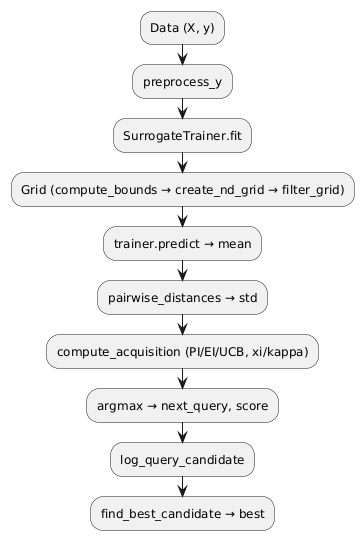

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    number-1  number-2  log-likelyhood-score  source
9   0.702637  0.926564              0.611205    file
13  0.691873  0.263356              0.596081  week-4
0   0.665800  0.123969              0.538996    file
12  0.722766  0.839711              0.533827  week-3
1   0.877791  0.778628              0.420586    file
3   0.845275  0.711120              0.293993    file
6   0.438166  0.685018              0.244619    file
4   0.454647  0.290455              0.214965    file
11  0.616162  1.000000              0.180119  week-2
10  0.818182  0.939394              0.051646  week-1
7   0.341750  0.028698              0.038749    file
5   0.577713  0.771973              0.023106    file
8   0.338648  0.213867             -0.013858    file
2   0.142699  0.349005             -0.065624    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_50430/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


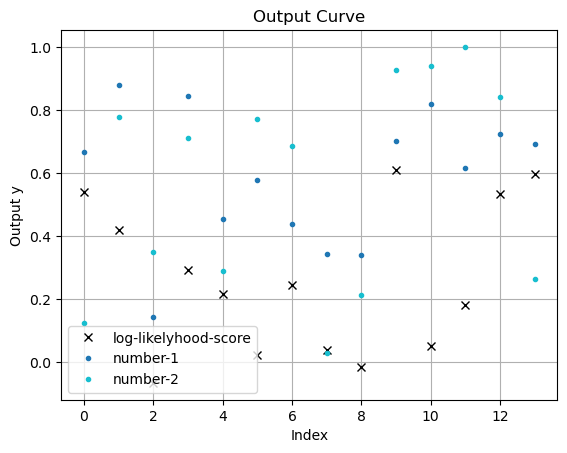

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
#row_lowest_A = df_sorted.loc[df["radiation-reading"].idxmin()]
#print(row_lowest_A)
#df_sorted.drop(df["radiation-reading"].idxmin(), inplace=True)
# Preview
#print(df_sorted)
#plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=1000, nan_marker='o')


In [4]:
X = inputs
y = outputs

In [5]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


In [6]:
def sweep_hyperparameters_NNtrain(X, y,
                                  xi_values=[0.01, 0.1, 0.3],
                                  kappa_values=[1.0, 2.0, 3.0],
                                  grid_sizes=[400],
                                  methods=['PI', 'EI', 'UCB'],
                                  apply_scaling=False,
                                  filter_mode='gp'):
    """
    Sweep hyperparameters for query selection using a trained NN surrogate.
    Applies Bayesian optimisation acquisition functions (PI, EI, UCB).
    """
    global query_results
    query_results = []

    # Step 1: preprocess targets
    y_proc = preprocess_y(y, apply_scaling=apply_scaling)

    # Step 2: train NN surrogate once
    trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)
    print("Epoch ", trainer.epochs)
    history = trainer.fit(X, y_proc, log_weights=True)
    # Plot loss curve
    plot_loss_curve(history)

    # Plot weight evolution (first layer mean)
    plot_weight_evolution(history, layer_name="model.0.weight", stat="mean")    

    # Step 3: loop over grid sizes
    for grid_size in grid_sizes:
        bounds = compute_bounds(X, margin=0.1)
        X_grid_full = create_nd_grid(bounds, grid_size)
        X_grid_filtered = filter_grid(X, y_proc, X_grid_full, filter_mode=filter_mode)

        if X_grid_filtered.shape[0] == 0:
            print(f"⚠️ Skipping grid_size={grid_size}, filter removed all points")
            continue

        # Step 4: predict surrogate outputs once per grid
        mean = trainer.predict(X_grid_filtered)
        
        # Step 5: uncertainty heuristic (distance to nearest training point)
        dist = pairwise_distances(X_grid_filtered, X)
        std = np.min(dist, axis=1)

        # Step 6: sweep acquisition hyperparameters
        for method in methods:
            if method in ['PI', 'EI']:
                for xi in xi_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, xi=xi)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, xi, next_query, score)

            elif method == 'UCB':
                for kappa in kappa_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, kappa=kappa)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, kappa, next_query, score)

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return X_grid_filtered, mean, bounds, best, query_results

Applying standard scaling to y.
Epoch  500
Epoch 1/500, Loss: 0.997593
Epoch 50/500, Loss: 0.375857
Epoch 100/500, Loss: 0.305049
Epoch 150/500, Loss: 0.202721
Epoch 200/500, Loss: 0.090179
Epoch 250/500, Loss: 0.032268
Epoch 300/500, Loss: 0.016974
Epoch 350/500, Loss: 0.007823
Epoch 400/500, Loss: 0.002887
Epoch 450/500, Loss: 0.000820
Epoch 500/500, Loss: 0.000183


/Users/ajay.amrite/Documents/AI Course/Anaconda Files/Module - 12/Black-Box functions/utils/SurrogateNN.py:81: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


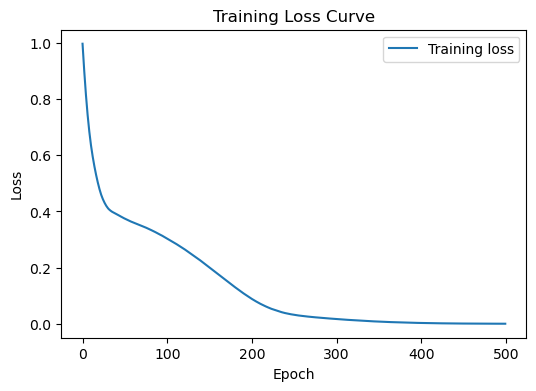

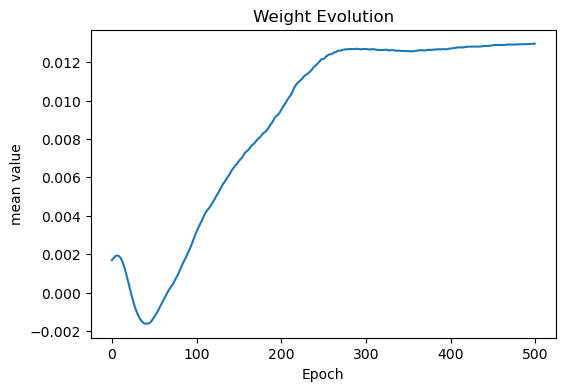

Computing bounds with margin 0.1.
Bounds per feature: [(0.04269907423594607, 0.9777909889953303), (-0.07130228017772214, 1.1)]
Creating 400^(2) grid.
Grid shape: (160000, 2)
Filtering grid using mode: gp
Grid shape before filtering: (160000, 2)
Filtered 2217 candidates near decision boundary (|margin| < 0.2)
Excluded 157783 candidates from consideration
Final grid shape: (2217, 2)
Filtered grid shape: (2217, 2)
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: UCB
Computing acquisition for method: UCB
Computing acquisition for method: UCB
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.78092953, 0.09309102]), 'score': 0.9999995573681162, 'dim': 2}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.78327312, 0.09602662]), 'score': 

In [7]:
X_grid_filtered, mean, bounds, best, query_results = sweep_hyperparameters_NNtrain(X, y, apply_scaling=True, filter_mode='gp')

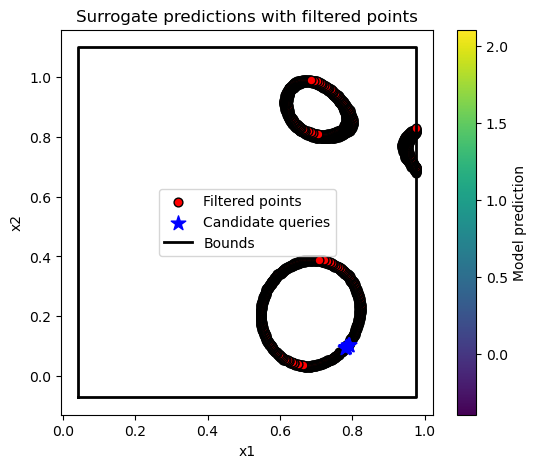

In [8]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean, 
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="Surrogate predictions with filtered points")


In [9]:
print("Best Hyperparameter Configuration:")
print(best)

Best Hyperparameter Configuration:
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.79030389, 0.1048334 ]), 'score': 2.4808345728605503, 'dim': 2}


In [10]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    number-1  number-2  log-likelyhood-score  source
9   0.702637  0.926564              0.611205    file
13  0.691873  0.263356              0.596081  week-4
0   0.665800  0.123969              0.538996    file
12  0.722766  0.839711              0.533827  week-3
1   0.877791  0.778628              0.420586    file
3   0.845275  0.711120              0.293993    file
6   0.438166  0.685018              0.244619    file
4   0.454647  0.290455              0.214965    file
11  0.616162  1.000000              0.180119  week-2
10  0.818182  0.939394              0.051646  week-1
7   0.341750  0.028698              0.038749    file
5   0.577713  0.771973              0.023106    file
8   0.338648  0.213867             -0.013858    file
2   0.142699  0.349005             -0.065624    file
14  0.780930  0.093091                   NaN  week-x
15  0.783273  0.096027                   NaN  week-x
16  0.783273  0.096027                   NaN  week-x
17  0.783273  0.096027                   NaN  

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_50430/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


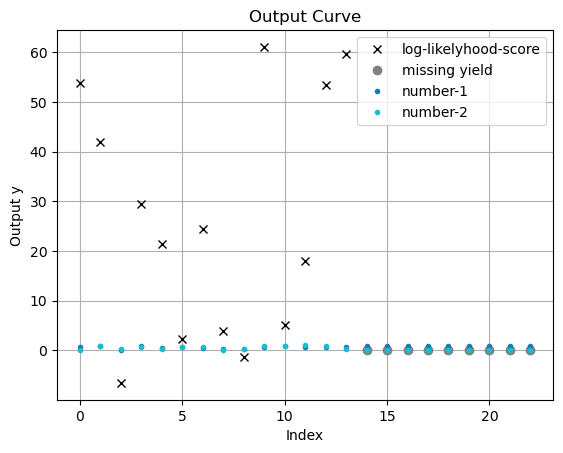

In [11]:
plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=100.0, nan_marker='o')